# Chapter 3 - Deep Q-learning (Keras Version, Fast Training)
### Deep Reinforcement Learning *in Action*
#### Based on **Listing 3.7** from `DQN.ipynb`, reimplemented with **Keras (TensorFlow)**.
#### Environment mode: **`random`**

---
**Speed optimizations over naive Keras:**
- `model.predict()` replaced with direct `model(x, training=False)` call (avoids Python dispatch overhead)
- `train_on_batch()` replaced with `tf.GradientTape` + `optimizer.apply_gradients()` (avoids high-level API cost)
- `@tf.function` JIT compilation applied to the training step (graph-mode speedup)

##### Setup: Clone Repo

In [1]:
# [Keras Modified] Replaced PyTorch import with TensorFlow / Keras imports
!git clone https://github.com/DeepReinforcementLearning/DeepReinforcementLearningInAction.git
import os
os.chdir('DeepReinforcementLearningInAction/Chapter 3')

import tensorflow as tf
from tensorflow import keras
print(f'TensorFlow version: {tf.__version__}')
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

Cloning into 'DeepReinforcementLearningInAction'...
remote: Enumerating objects: 264, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 264 (delta 12), reused 7 (delta 7), pack-reused 244 (from 3)
Receiving objects: 100% (264/264), 3.71 MiB | 17.19 MiB/s, done.
Resolving deltas: 100% (75/75), done.
TensorFlow version: 2.20.0
GPU available: True


##### Model & Hyperparameters

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from Gridworld import Gridworld
from IPython.display import clear_output
import random
from matplotlib import pylab as plt
from collections import deque

l1 = 64
l2 = 150
l3 = 100
l4 = 4

# [Keras Modified] Replaced torch.nn.Sequential with keras.Sequential
model = keras.Sequential([
    layers.Dense(l2, activation='relu', input_shape=(l1,)),
    layers.Dense(l3, activation='relu'),
    layers.Dense(l4, activation='linear')
])

learning_rate = 1e-3

# [Keras Modified] Use keras optimizer; loss is computed manually in GradientTape below
# Original slow version used: model.compile(..., loss='mse') + model.train_on_batch()
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
loss_fn = keras.losses.MeanSquaredError()

gamma = 0.9
epsilon = 0.3

action_set = {
    0: 'u',
    1: 'd',
    2: 'l',
    3: 'r',
}

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##### [Speed Optimization] JIT-compiled Training Step

Using `@tf.function` converts the training step into a TensorFlow **graph** (compiled once, runs fast every call).  
This is equivalent to the speed gain from PyTorch's C++ backend for individual forward/backward passes.

In [3]:
# [Speed Modified] Extracted the training step into a @tf.function for JIT compilation
# Original slow version: model.train_on_batch(state1_batch, Q_target)  -- no JIT, high Python overhead
@tf.function
def train_step(state1_batch, action_batch, Y_target):
    """One gradient update. Runs in TF graph mode (fast)."""
    with tf.GradientTape() as tape:
        Q1 = model(state1_batch, training=True)  # forward pass with grad tracking
        # Gather Q-values for the actions that were actually taken
        batch_idx = tf.range(tf.shape(action_batch)[0])
        indices = tf.stack([batch_idx, tf.cast(action_batch, tf.int32)], axis=1)
        X = tf.gather_nd(Q1, indices)            # Q(s, a_taken)
        loss = loss_fn(Y_target, X)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

##### Listing 3.7 ??Experience Replay DQN (Keras, Optimized)

In [4]:
epochs = 5000
losses = []
mem_size = 1000   #A
batch_size = 200  #B
replay = deque(maxlen=mem_size)  #C
max_moves = 50    #D
mov = 0

for i in range(epochs):
    # [Keras Modified] mode='random' as required
    game = Gridworld(size=4, mode='random')

    # [Keras Modified] state stays as float32 NumPy array (no torch.from_numpy / .to(device))
    state1 = game.board.render_np().reshape(1, 64).astype(np.float32) + np.random.rand(1, 64).astype(np.float32) / 100.0
    status = 1
    mov = 0

    while status == 1:
        mov += 1

        # [Speed Modified] model(x, training=False) instead of model.predict(x)
        # model.predict() has large Python dispatch overhead per call;
        # direct __call__ is near-zero overhead (same as PyTorch model(x))
        qval = model(state1, training=False).numpy()  #E

        if random.random() < epsilon:  #F
            action_ = np.random.randint(0, 4)
        else:
            action_ = np.argmax(qval)

        action = action_set[action_]
        game.makeMove(action)

        # [Keras Modified] state2 stays as float32 NumPy array
        state2 = game.board.render_np().reshape(1, 64).astype(np.float32) + np.random.rand(1, 64).astype(np.float32) / 100.0
        reward = game.reward()
        done = True if reward > 0 else False
        exp = (state1, action_, reward, state2, done)  #G
        replay.append(exp)  #H
        state1 = state2

        if len(replay) > batch_size:  #I
            minibatch = random.sample(replay, batch_size)  #J

            # [Keras Modified] np.vstack instead of torch.cat to build batches
            state1_batch = np.vstack([s1 for (s1, a, r, s2, d) in minibatch]).astype(np.float32)  #K
            action_batch = np.array([a for (s1, a, r, s2, d) in minibatch], dtype=np.int32)
            reward_batch = np.array([r for (s1, a, r, s2, d) in minibatch], dtype=np.float32)
            state2_batch = np.vstack([s2 for (s1, a, r, s2, d) in minibatch]).astype(np.float32)
            done_batch   = np.array([d for (s1, a, r, s2, d) in minibatch], dtype=np.float32)

            # [Speed Modified] model(x, training=False) for Q2 instead of model.predict()
            # No gradient tracking needed here (equivalent to torch.no_grad())
            Q2 = model(state2_batch, training=False).numpy()  #M

            # [Keras Modified] Compute Bellman targets in NumPy
            # Original PyTorch: Y = reward_batch + gamma * ((1-done_batch) * torch.max(Q2,dim=1)[0])
            Y_target = (reward_batch + gamma * (1.0 - done_batch) * np.max(Q2, axis=1)).astype(np.float32)  #N

            # [Speed Modified] Call the @tf.function compiled train_step instead of train_on_batch()
            # First call triggers JIT compilation; all subsequent calls run in graph mode (fast)
            loss = train_step(
                tf.constant(state1_batch),
                tf.constant(action_batch),
                tf.constant(Y_target)
            )

            losses.append(float(loss))
            print(i, float(loss))
            clear_output(wait=True)

        if reward != -1 or mov > max_moves:  #O
            status = 0
            mov = 0

losses = np.array(losses)

#A Set the total size of the experience replay memory
#B Set the minibatch size
#C Create the memory replay as a deque list
#D Maximum number of moves before game is over
#E Compute Q-values (fast direct call, no predict() overhead)
#F Select action using epsilon-greedy strategy
#G Create experience tuple (state, action, reward, next_state, done)
#H Add experience to replay buffer
#I If replay buffer is large enough, start training
#J Randomly sample a minibatch
#K Build minibatch arrays from sampled experiences
#M Compute target Q-values with no gradient tracking
#N Compute Bellman targets
#O If game is over, reset status and move counter

4999 0.07928372174501419


##### Loss Plot

Text(0.5, 1.0, 'DQN Keras (Optimized) ??mode=random')

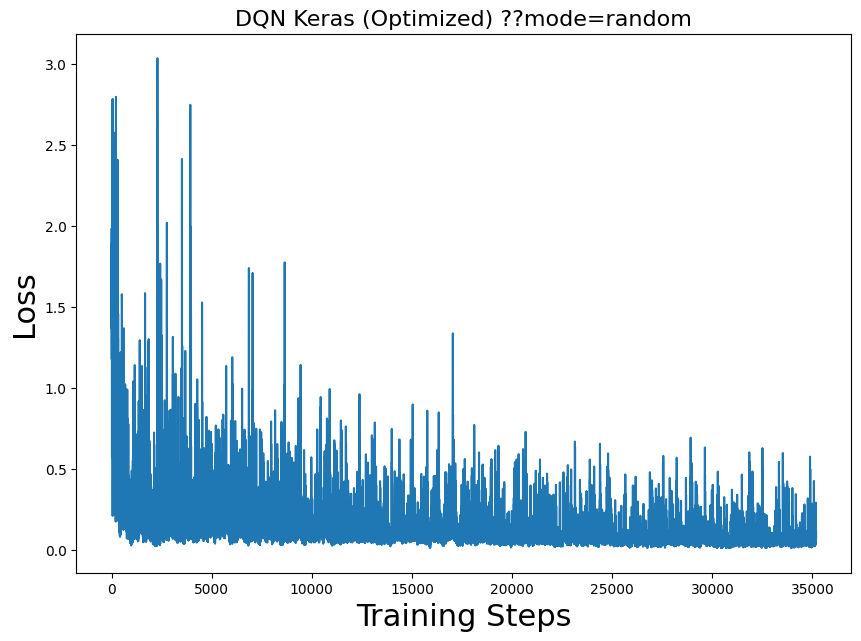

In [5]:
plt.figure(figsize=(10, 7))
plt.plot(losses)
plt.xlabel("Training Steps", fontsize=22)
plt.ylabel("Loss", fontsize=22)
plt.title("DQN Keras (Optimized) ??mode=random", fontsize=16)

##### Test Model

In [6]:
# [Speed Modified] test_model also uses model(x, training=False) instead of model.predict()
def test_model(model, mode='static', display=True):
    i = 0
    test_game = Gridworld(mode=mode)
    state = test_game.board.render_np().reshape(1, 64).astype(np.float32) + np.random.rand(1, 64).astype(np.float32) / 10.0
    if display:
        print("Initial State:")
        print(test_game.display())
    status = 1
    while status == 1:
        qval = model(state, training=False).numpy()  # fast direct call
        action_ = np.argmax(qval)
        action = action_set[action_]
        if display:
            print('Move #: %s; Taking action: %s' % (i, action))
        test_game.makeMove(action)
        state = test_game.board.render_np().reshape(1, 64).astype(np.float32) + np.random.rand(1, 64).astype(np.float32) / 10.0
        if display:
            print(test_game.display())
        reward = test_game.reward()
        if reward != -1:
            if reward > 0:
                status = 2
                if display:
                    print("Game won! Reward: %s" % (reward,))
            else:
                status = 0
                if display:
                    print("Game LOST. Reward: %s" % (reward,))
        i += 1
        if i > 15:
            if display:
                print("Game lost; too many moves.")
            break
    return True if status == 2 else False

In [7]:
max_games = 1000
wins = 0
for i in range(max_games):
    if test_model(model, mode='random', display=False):
        wins += 1
win_perc = float(wins) / float(max_games)
print("Games played: {0}, # of wins: {1}".format(max_games, wins))
print("Win percentage: {}%".format(100.0 * win_perc))

Games played: 1000, # of wins: 883
Win percentage: 88.3%
